# 48 - FCNN conf60 4-class

**Dataset:** Front-only conf60 (confidence >= 60%)
**Skenario:** B1 (Baseline), B2 (Class Weights), B3 (Weights + Augmentasi)

In [1]:
import sys, os, json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader
from collections import Counter

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import EmotionFCNN
from training.utils import (
    EmotionImageDataset, EmotionLandmarkDataset, EmotionMultimodalDataset,
    get_class_weights, train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DATASET_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_conf60_4class"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_conf60_4class_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "frontonly_conf60" / "4class"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 50
LR = 0.0001
PATIENCE = 15
NUM_CLASSES = 4
EMOTIONS = ["neutral", "happy", "sad", "negative"]

print(f"Dataset: {DATASET_DIR}")
print(f"Dataset Aug: {DATASET_AUG_DIR}")
print(f"Output: {OUTPUT_DIR}")

Device: cuda
GPU: Tesla T4
Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_conf60_4class
Dataset Aug: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_conf60_4class_augmented
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class


In [2]:
def load_dataloaders(dataset_dir, batch_size=32):
    loaders = {}
    for split in ["train", "val", "test"]:
        ds = EmotionLandmarkDataset(dataset_dir / f"X_{split}_landmarks.npy", dataset_dir / f"y_{split}.npy")
        loaders[split] = DataLoader(ds, batch_size=batch_size, shuffle=(split=="train"), num_workers=2, pin_memory=True)
    y = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y.tolist())
    print(f"Train: {len(y)} | Val: {len(np.load(dataset_dir / 'y_val.npy'))} | Test: {len(np.load(dataset_dir / 'y_test.npy'))}")
    for i, e in enumerate(EMOTIONS): print(f"  {e:>10s}: {counts.get(i, 0)}")
    return loaders["train"], loaders["val"], loaders["test"]

train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Train: 5287 | Val: 579 | Test: 929
     neutral: 4526
       happy: 416
         sad: 287
    negative: 58


## Training B1, B2, B3


Training B1 (baseline)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.1983     0.5311     1.0351    0.8031   0.2309   0.000100  (1.1s)


     2      0.7235     0.8419     0.7994    0.8221   0.2256   0.000100  (0.9s)


     3      0.5776     0.8553     0.7239    0.8187   0.2571   0.000100  (1.0s)


     4      0.5211     0.8566     0.6345    0.8221   0.2346   0.000100  (0.9s)


...

    36      0.3478     0.8778     0.5673    0.8342   0.4095   0.000025  (1.0s)


    37      0.3496     0.8850     0.7607    0.8480   0.3911   0.000025  (0.9s)


    38      0.3486     0.8803     0.7295    0.8446   0.4272   0.000025  (0.9s)


    39      0.3457     0.8795     0.6284    0.8394   0.3775   0.000025  (0.9s)


    40      0.3424     0.8835     0.6519    0.8394   0.4266   0.000025  (1.0s)

Early stopping at epoch 40. Best epoch: 25 (val_f1=0.4773)

Best: epoch 25, val_acc=0.8204, val_f1=0.4773
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class/fcnn_b1.pth


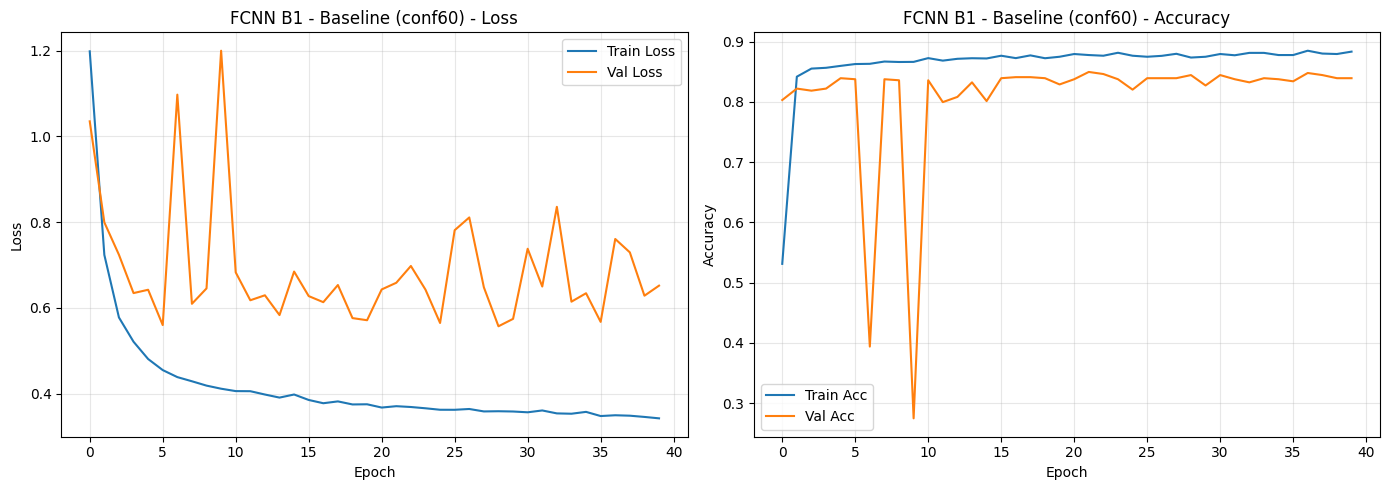

Test Loss: 0.6372
Test Accuracy: 0.6954
Test Macro F1: 0.4224
Test Weighted F1: 0.7218

Classification Report:
              precision    recall  f1-score   support

     neutral       0.92      0.68      0.78       688
       happy       0.53      0.84      0.65       183
         sad       0.18      0.46      0.26        50
    negative       0.00      0.00      0.00         8

    accuracy                           0.70       929
   macro avg       0.41      0.49      0.42       929
weighted avg       0.79      0.70      0.72       929



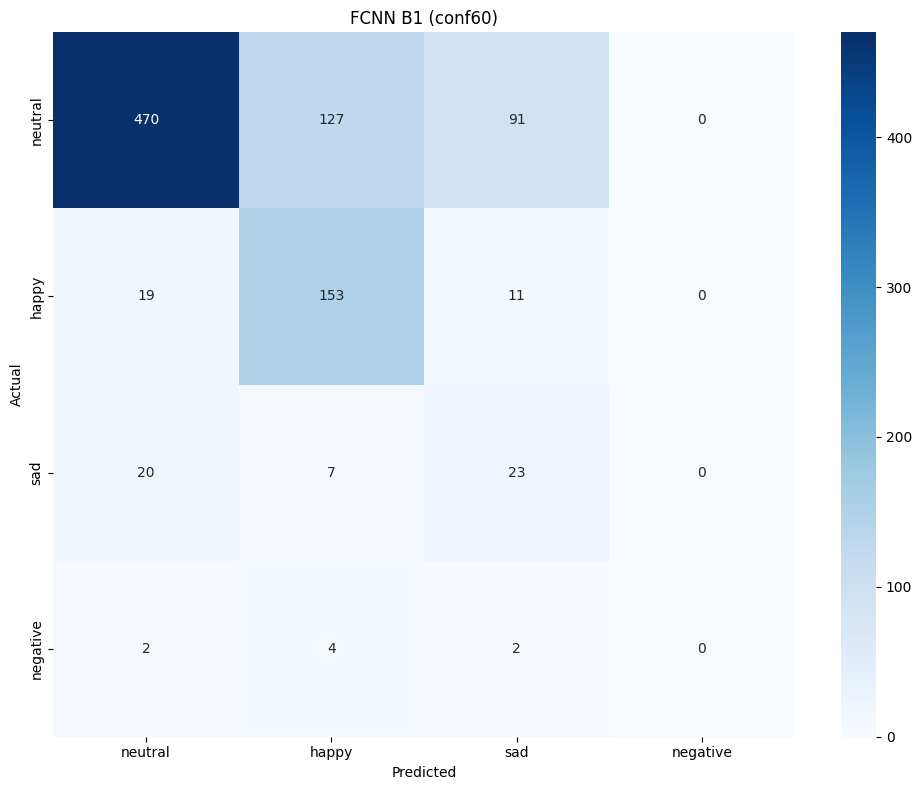

B1: Acc=0.6954 F1=0.4224

Class weights: None
Training B2 (class weights)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.1454     0.5716     0.9914    0.8152   0.2245   0.000100  (1.0s)


     2      0.7121     0.8466     0.7744    0.8238   0.2259   0.000100  (1.0s)


     3      0.5856     0.8542     0.6877    0.8221   0.2256   0.000100  (0.9s)


     4      0.5304     0.8561     0.6798    0.8273   0.2678   0.000100  (0.9s)


...

    33      0.3515     0.8807     0.6878    0.8394   0.4273   0.000025  (0.9s)


    34      0.3455     0.8824     0.6151    0.8342   0.4402   0.000025  (1.0s)


    35      0.3472     0.8835     0.7562    0.8411   0.3540   0.000025  (1.0s)


    36      0.3470     0.8797     0.7744    0.8411   0.3510   0.000025  (0.9s)


    37      0.3505     0.8782     0.6287    0.8394   0.4287   0.000025  (0.9s)

Early stopping at epoch 37. Best epoch: 22 (val_f1=0.4476)

Best: epoch 22, val_acc=0.8187, val_f1=0.4476
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class/fcnn_b2.pth


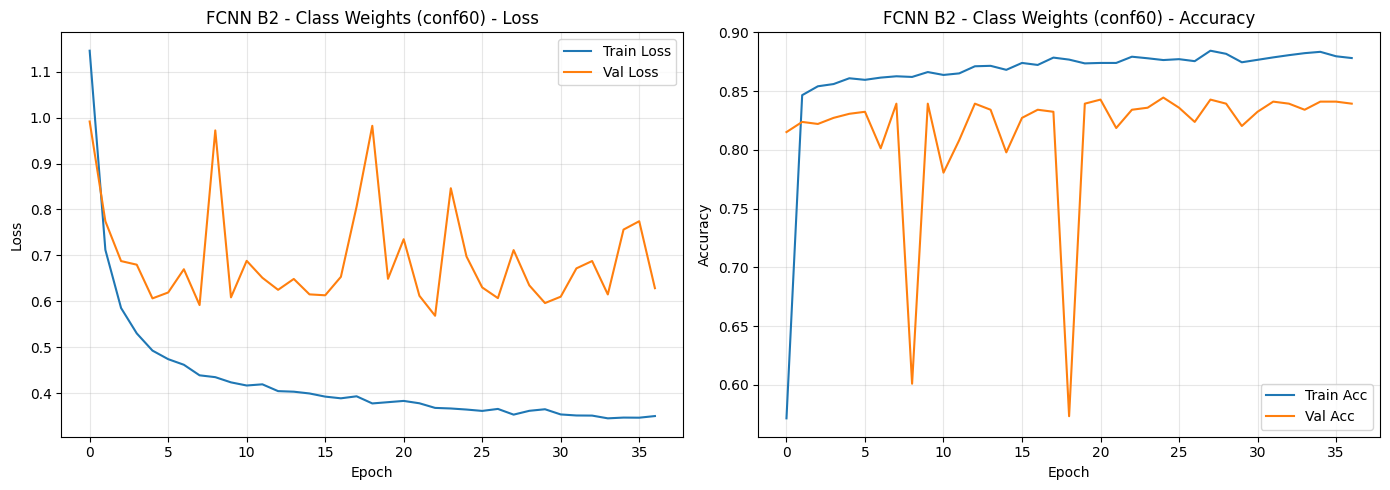

Test Loss: 0.5939
Test Accuracy: 0.7567
Test Macro F1: 0.4595
Test Weighted F1: 0.7830

Classification Report:
              precision    recall  f1-score   support

     neutral       0.91      0.81      0.85       688
       happy       0.74      0.63      0.68       183
         sad       0.20      0.64      0.30        50
    negative       0.00      0.00      0.00         8

    accuracy                           0.76       929
   macro avg       0.46      0.52      0.46       929
weighted avg       0.83      0.76      0.78       929



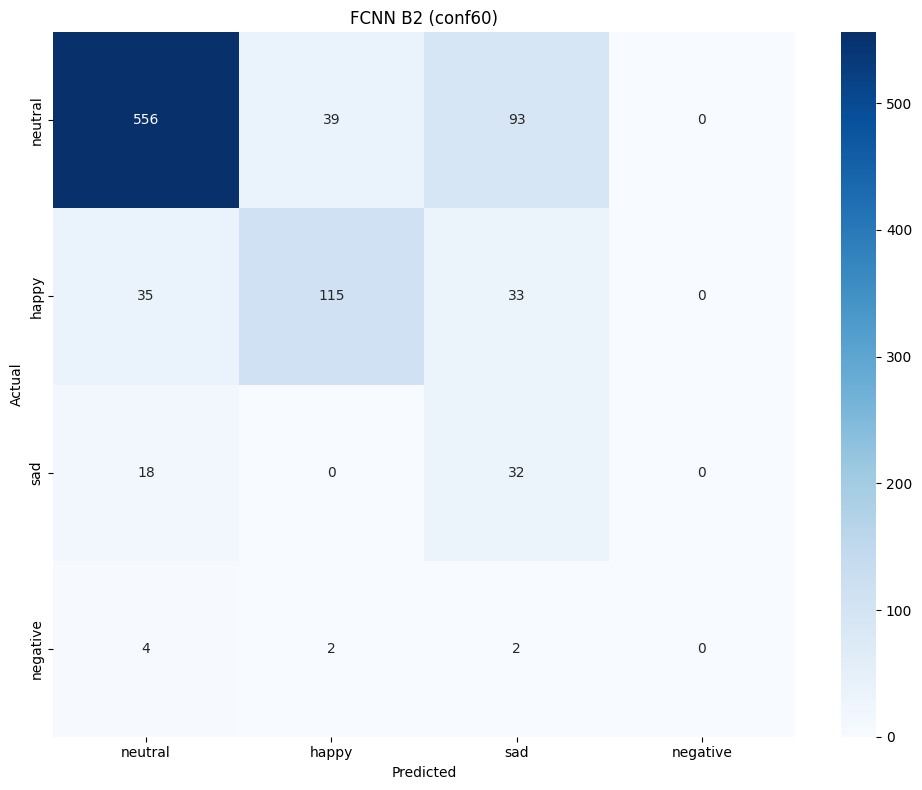

B2: Acc=0.7567 F1=0.4595
Train: 5829 | Val: 579 | Test: 929
     neutral: 4526
       happy: 416
         sad: 287
    negative: 600

Training B3 (class weights + augmented)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.0280     0.6560     0.7735    0.8152   0.2245   0.000100  (1.0s)


     2      0.7257     0.8007     0.6729    0.8221   0.2256   0.000100  (1.0s)


     3      0.6537     0.8106     0.6800    0.8221   0.2256   0.000100  (1.1s)


     4      0.6176     0.8135     0.7750    0.7927   0.2689   0.000100  (1.1s)


...

    24      0.4389     0.8504     0.6560    0.7893   0.4228   0.000050  (1.0s)


    25      0.4350     0.8525     0.6897    0.8411   0.3556   0.000050  (1.0s)


    26      0.4361     0.8489     0.5780    0.8307   0.3550   0.000050  (1.1s)


    27      0.4353     0.8482     0.6131    0.8394   0.4024   0.000050  (1.0s)


    28      0.4320     0.8475     0.6084    0.8083   0.3506   0.000050  (1.0s)

Early stopping at epoch 28. Best epoch: 13 (val_f1=0.4661)

Best: epoch 13, val_acc=0.8273, val_f1=0.4661
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class/fcnn_b3.pth


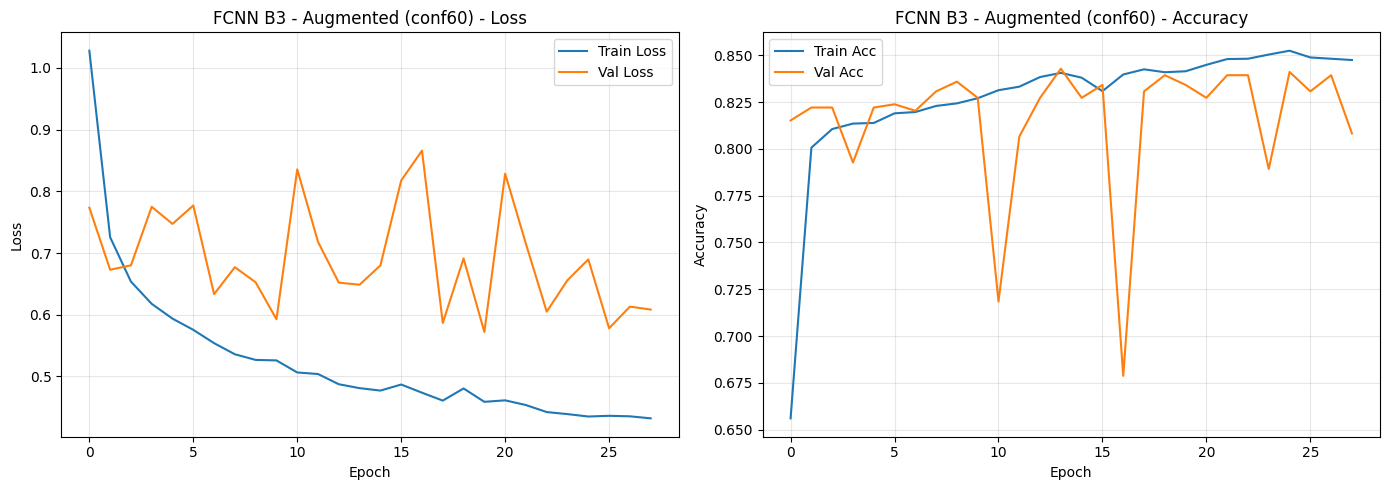

Test Loss: 0.7361
Test Accuracy: 0.7018
Test Macro F1: 0.4214
Test Weighted F1: 0.7394

Classification Report:
              precision    recall  f1-score   support

     neutral       0.90      0.74      0.81       688
       happy       0.61      0.71      0.66       183
         sad       0.11      0.18      0.14        50
    negative       0.04      0.38      0.08         8

    accuracy                           0.70       929
   macro avg       0.42      0.50      0.42       929
weighted avg       0.79      0.70      0.74       929



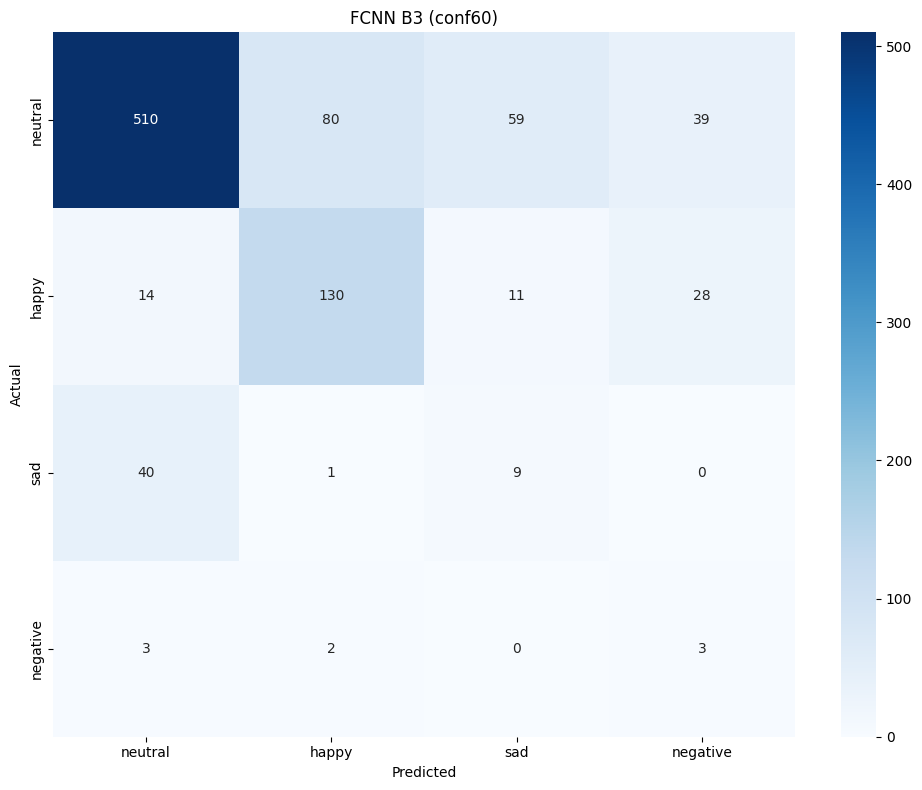

B3: Acc=0.7018 F1=0.4214

RINGKASAN FCNN (conf60)
  B1 Baseline               Acc=0.6954 F1=0.4224
  B2 Class Weights          Acc=0.7567 F1=0.4595
  B3 Weights+Aug            Acc=0.7018 F1=0.4214

Saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class/fcnn_results.json


In [3]:
all_results = {}

# B1: Baseline
model_b1 = EmotionFCNN(num_classes=NUM_CLASSES).to(device)
criterion_b1 = nn.CrossEntropyLoss()
optimizer_b1 = torch.optim.Adam(model_b1.parameters(), lr=LR)
scheduler_b1 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b1, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("\nTraining B1 (baseline)...")
history_b1, _ = train_model(model_b1, train_loader, val_loader, criterion_b1, optimizer_b1, scheduler_b1,
    device, model_type="fcnn", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "fcnn_b1.pth"))
plot_training_history(history_b1, "FCNN B1 - Baseline (conf60)")
model_b1.load_state_dict(torch.load(OUTPUT_DIR / "fcnn_b1.pth", map_location=device, weights_only=True))
r_b1 = full_evaluation(model_b1, test_loader, criterion_b1, device, "fcnn", EMOTIONS)
plot_confusion_matrix(r_b1["confusion_matrix"], "FCNN B1 (conf60)", EMOTIONS)
all_results["B1 Baseline"] = {"accuracy": float(r_b1["test_accuracy"]), "macro_f1": float(r_b1["test_macro_f1"]), "weighted_f1": float(r_b1["test_weighted_f1"])}
print(f"B1: Acc={r_b1['test_accuracy']:.4f} F1={r_b1['test_macro_f1']:.4f}")

# B2: Class Weights
weights = get_class_weights(DATASET_DIR, device)
print(f"\nClass weights: {weights}")
model_b2 = EmotionFCNN(num_classes=NUM_CLASSES).to(device)
criterion_b2 = nn.CrossEntropyLoss(weight=weights)
optimizer_b2 = torch.optim.Adam(model_b2.parameters(), lr=LR)
scheduler_b2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b2, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("Training B2 (class weights)...")
history_b2, _ = train_model(model_b2, train_loader, val_loader, criterion_b2, optimizer_b2, scheduler_b2,
    device, model_type="fcnn", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "fcnn_b2.pth"))
plot_training_history(history_b2, "FCNN B2 - Class Weights (conf60)")
model_b2.load_state_dict(torch.load(OUTPUT_DIR / "fcnn_b2.pth", map_location=device, weights_only=True))
r_b2 = full_evaluation(model_b2, test_loader, criterion_b2, device, "fcnn", EMOTIONS)
plot_confusion_matrix(r_b2["confusion_matrix"], "FCNN B2 (conf60)", EMOTIONS)
all_results["B2 Class Weights"] = {"accuracy": float(r_b2["test_accuracy"]), "macro_f1": float(r_b2["test_macro_f1"]), "weighted_f1": float(r_b2["test_weighted_f1"])}
print(f"B2: Acc={r_b2['test_accuracy']:.4f} F1={r_b2['test_macro_f1']:.4f}")

# B3: Class Weights + Augmented
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
model_b3 = EmotionFCNN(num_classes=NUM_CLASSES).to(device)
criterion_b3 = nn.CrossEntropyLoss(weight=weights_aug)
optimizer_b3 = torch.optim.Adam(model_b3.parameters(), lr=LR)
scheduler_b3 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b3, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("\nTraining B3 (class weights + augmented)...")
history_b3, _ = train_model(model_b3, train_loader_aug, val_loader, criterion_b3, optimizer_b3, scheduler_b3,
    device, model_type="fcnn", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "fcnn_b3.pth"))
plot_training_history(history_b3, "FCNN B3 - Augmented (conf60)")
model_b3.load_state_dict(torch.load(OUTPUT_DIR / "fcnn_b3.pth", map_location=device, weights_only=True))
r_b3 = full_evaluation(model_b3, test_loader, criterion_b3, device, "fcnn", EMOTIONS)
plot_confusion_matrix(r_b3["confusion_matrix"], "FCNN B3 (conf60)", EMOTIONS)
all_results["B3 Weights+Aug"] = {"accuracy": float(r_b3["test_accuracy"]), "macro_f1": float(r_b3["test_macro_f1"]), "weighted_f1": float(r_b3["test_weighted_f1"])}
print(f"B3: Acc={r_b3['test_accuracy']:.4f} F1={r_b3['test_macro_f1']:.4f}")

# Summary
print("\n" + "=" * 60)
print("RINGKASAN FCNN (conf60)")
print("=" * 60)
for name, r in all_results.items():
    print(f"  {name:<25} Acc={r['accuracy']:.4f} F1={r['macro_f1']:.4f}")

with open(OUTPUT_DIR / "fcnn_results.json", "w") as f:
    json.dump(all_results, f, indent=2)
print(f"\nSaved: {OUTPUT_DIR / 'fcnn_results.json'}")